In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Tuple
import argparse
from scipy.special import lpmv
from scipy.ndimage import uniform_filter1d
import matplotlib.ticker as mticker

Forming the Grid and Wavefunction

In [38]:
def build_grid(L: float, N: int) -> Tuple[np.ndarray, float]:
  x = np.linspace(-L, L, N)
  dx = x[1] - x[0]
  return x, dx

def build_bound_states(lam: int, x: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
  u = np.tanh(x)
  mus = np.arange(lam, 0, -1)
  states = len(mus)
  raw = np.zeros((states, x.size), dtype=float)
  for i, mu in enumerate(mus):
    raw[i,:] = lpmv(int(mu), int(lam), u)
  return mus, raw

def normalize_wavefunction(raw: np.ndarray, x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    states = raw.shape[0]
    wavefunction = np.zeros_like(raw)
    norms = np.zeros(states)
    for i in range(states):
        sq = np.abs(raw[i, :] ** 2)
        norm_i = np.trapezoid(sq, x)
        norms[i] = norm_i
        wavefunction[i, :] = raw[i, :] / np.sqrt(norm_i)
    return wavefunction, norms

def compute_matrice(wavefunction: np.ndarray, x: np.ndarray, dx: float) -> Tuple[np.ndarray, np.ndarray]:
  n = wavefunction.shape[0]
  x_matrice = np.zeros((n, n), dtype=float)
  p_matrice = np.zeros((n, n), dtype=complex)
  d_wavefunction = np.gradient(wavefunction, dx, axis=1)
  for i in range(n):
    for j in range(n):
      x_matrice[i, j] = np.trapezoid(wavefunction[i, :] * wavefunction[j, :] * x, x)
      p_matrice[i, j] = (-1j) * np.trapezoid(wavefunction[i, :] * d_wavefunction[j, :], x)
  x_matrice = np.real_if_close(x_matrice, tol=1e6)
  return x_matrice, p_matrice

def energies_from_Mu(Mu: np.ndarray) -> np.ndarray:
  return -0.5 * (Mu ** 2)

OTOC Calculation for Poschl-Teller Potential

In [39]:
def microcanonical_OTOC(Energy: np.ndarray, x_matrice: np.ndarray, p_matrice: np.ndarray, Mu_index: int, t_array: np.ndarray) -> np.ndarray:
  Cvalues = np.zeros_like(t_array, dtype=float)
  deltaE = Energy[:, None] - Energy[None, :]
  for k, t in enumerate(t_array):
    phases = np.exp(1j * deltaE * t)
    x_t = x_matrice * phases
    commutator = x_t @ p_matrice - p_matrice @ x_t
    commutator = commutator @ commutator
    Cvalues[k] = -np.real(commutator[Mu_index, Mu_index])
  return Cvalues

def thermal_OTOC(Energy: np.ndarray, x_matrice: np.ndarray, p_matrice: np.ndarray, beta: float, t_array: np.ndarray) -> np.ndarray:
  weights = np.exp(-1 * beta * Energy)
  Z = np.sum(weights)
  Csum = np.zeros_like(t_array, dtype=float)
  for Mu_index in range(len(Energy)):
    Cmu = microcanonical_OTOC(Energy, x_matrice, p_matrice, Mu_index, t_array)
    Csum += weights[Mu_index] * Cmu
  return Csum / Z

Visualisation Functions

In [40]:
def adaptive_downsample(x, y, max_points=2000):
    if len(x) > max_points:
        step = len(x) // max_points
        return x[::step], y[::step]
    return x, y

def add_text_label_to_line(ax, x, y, text, x_pos_ratio=0.5, color='black'):
    if len(x) == 0 or len(y) == 0:
        return
    idx = int(len(x) * x_pos_ratio)
    ax.text(x[idx], y[idx], text, color=color, fontsize=12,
            ha='center', va='bottom',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

def plot_time_series(t, C, label_text="", title="", color=None, ax=None, ylabel=""):

    positive_indices = np.where(C > 0)[0]
    if len(positive_indices) == 0:
        print(f"Warning: No positive data to plot for label '{label_text}'. Skipping.")
        return ax

    t_plot, C_plot = adaptive_downsample(t[positive_indices], C[positive_indices])

    create_new_figure = ax is None
    if create_new_figure:
        fig, ax = plt.subplots(figsize=(12, 6))
    else:
        fig = ax.figure

    n_val = None
    if "n =" in label_text:
        try:
            n_val = int(label_text.split('=')[-1].strip())
        except (ValueError, IndexError):
            pass

    colors = {1: '#8A2BE2', 2: '#228B22', 5: '#1E90FF', 10: '#FFD700'}
    plot_color = color or colors.get(n_val, 'gray')
    ax.plot(t_plot, C_plot, linewidth=2, color=plot_color, alpha=0.9)

    if label_text and n_val is not None:
        x_pos_map = {1: 0.5, 2: 0.25, 5: 0.45, 10: 0.18}
        x_pos = x_pos_map.get(n_val, 0.1)
        add_text_label_to_line(ax, t_plot, C_plot, label_text, x_pos_ratio=x_pos, color=plot_color)

    if create_new_figure or ax.get_ylabel() == '':
        ax.set_ylabel(ylabel if ylabel else r"$C_n(t)$", fontsize=14)

    ax.set_yscale("log")
    ax.set_xlabel("t", fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.grid(False)

    if create_new_figure:
        ax.set_title(title, fontsize=16)
        fig.tight_layout()
        plt.show()

    return ax



In [41]:
def compute_and_plot_otocs(lam: int, L: float = 12.0, N: int = 20001,
                           tmax: float = 50.0, nt: int = 1001,
                           betas: list = [10.0, 1.0, 0.1]):
    print(f"--- Processing lambda = {lam} ---")

    # --- 1. System Setup ---
    x, dx = build_grid(L, N)
    mus, raw = build_bound_states(lam, x)
    psis, norms = normalize_wavefunction(raw, x)
    x_mat, p_mat = compute_matrice(psis, x, dx)
    Es = energies_from_Mu(mus)
    t = np.linspace(0, tmax, nt)

    fig_combined, ax_combined = plt.subplots(figsize=(12, 6))
    mu_values_to_plot = sorted([1, 2, 5, 10], reverse=True)
    micro_otocs = {}
    all_positive_c_values = []

    for mu_val in mu_values_to_plot:
        if mu_val <= lam:
            mu_index = int(lam - mu_val)
            C_mu = microcanonical_OTOC(Es, x_mat, p_mat, mu_index, t)
            micro_otocs[f'mu_{mu_val}'] = C_mu
            positive_vals = C_mu[C_mu > 0]
            if len(positive_vals) > 0:
                all_positive_c_values.extend(positive_vals)
            plot_time_series(t, C_mu, label_text=f"n = {mu_val}", ax=ax_combined)

    if all_positive_c_values:
        min_y = np.min(all_positive_c_values)
        max_y = np.max(all_positive_c_values)
        ax_combined.set_ylim(min_y * 0.9, max_y * 1.1)

    ax_combined.set_title(f"Microcanonical OTOC for $\\lambda={lam}$", fontsize=16)
    fig_combined.tight_layout()
    plt.show()


    C_temps = {beta: thermal_OTOC(Es, x_mat, p_mat, beta, t) for beta in betas}
    for beta, C in C_temps.items():
        plot_time_series(
            t, C, ylabel="$C_T(t)$",
            title=f"Thermal OTOC ($\\beta={beta}$), $\\lambda={lam}$",
            color='darkblue'
        )

    print(f"Finished processing lambda = {lam}.")


    return {
        "mus": mus,
        "energies": Es,
        "time_array": t,
        "micro_otocs": micro_otocs,
        "thermal_otocs": C_temps
    }

Starting Pöschl-Teller OTOC computations...
--- Processing lambda = 10 ---


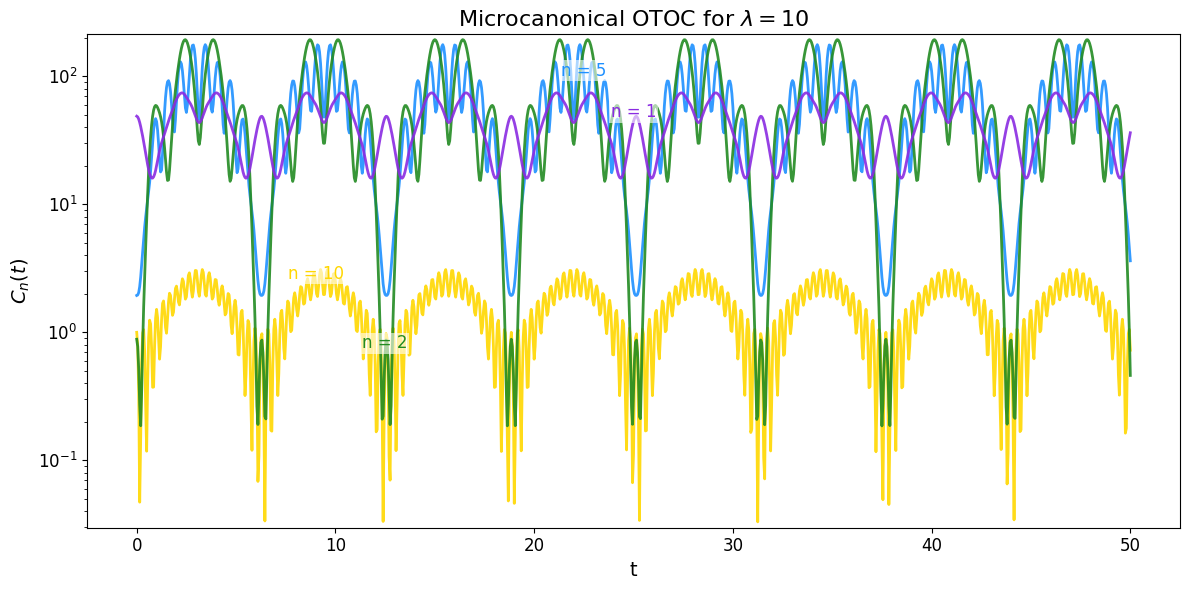

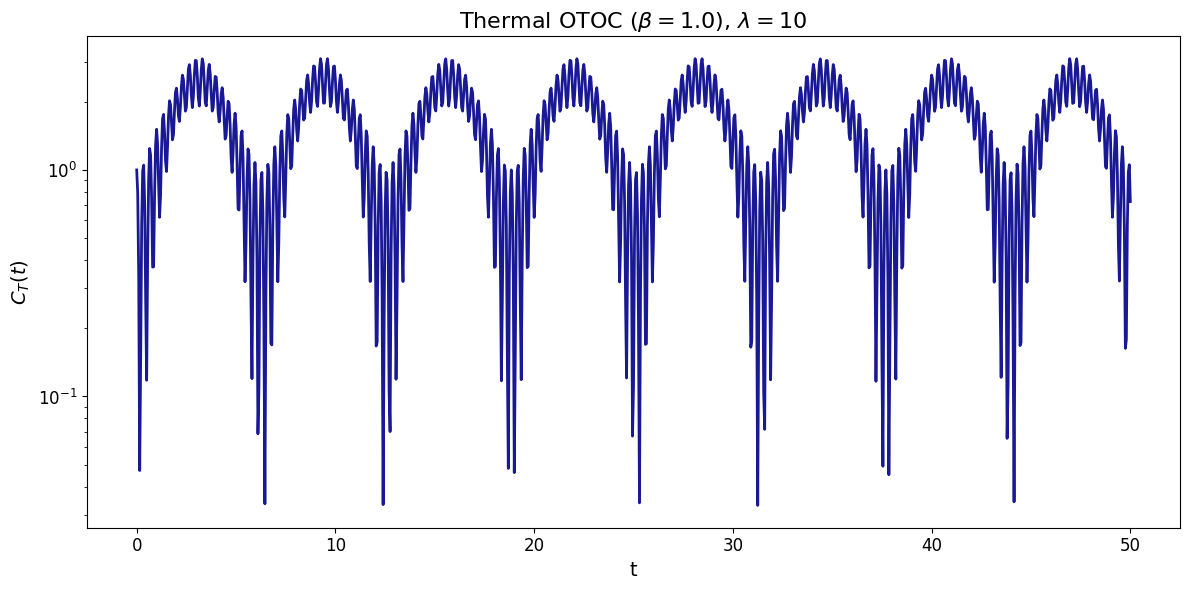

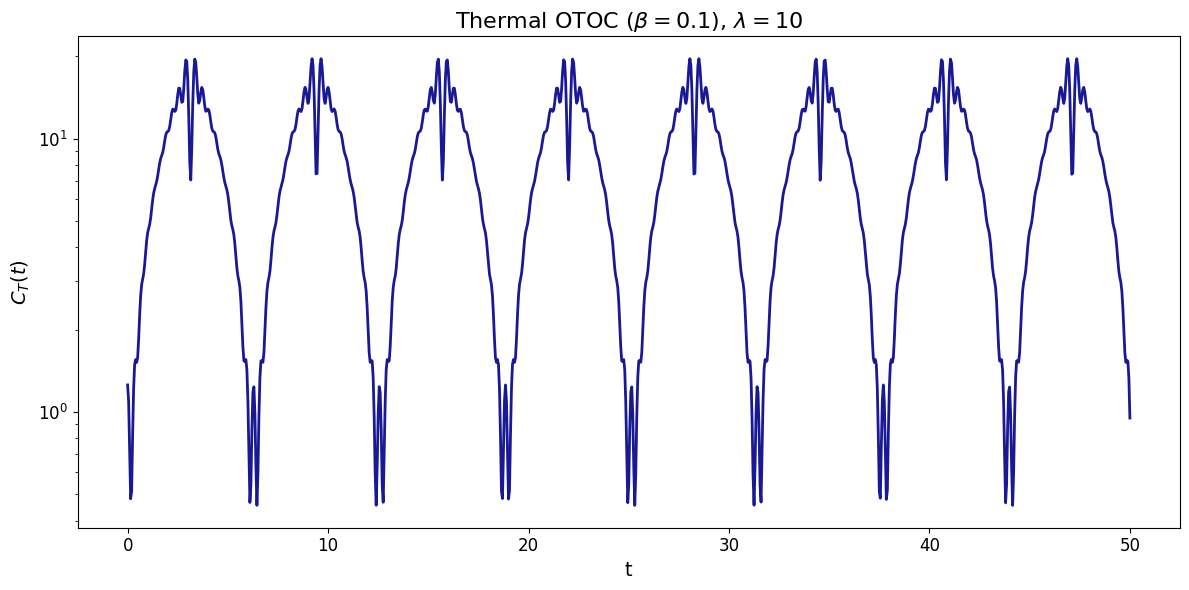

Finished processing lambda = 10.
--------------------------------------------------
--- Processing lambda = 15 ---


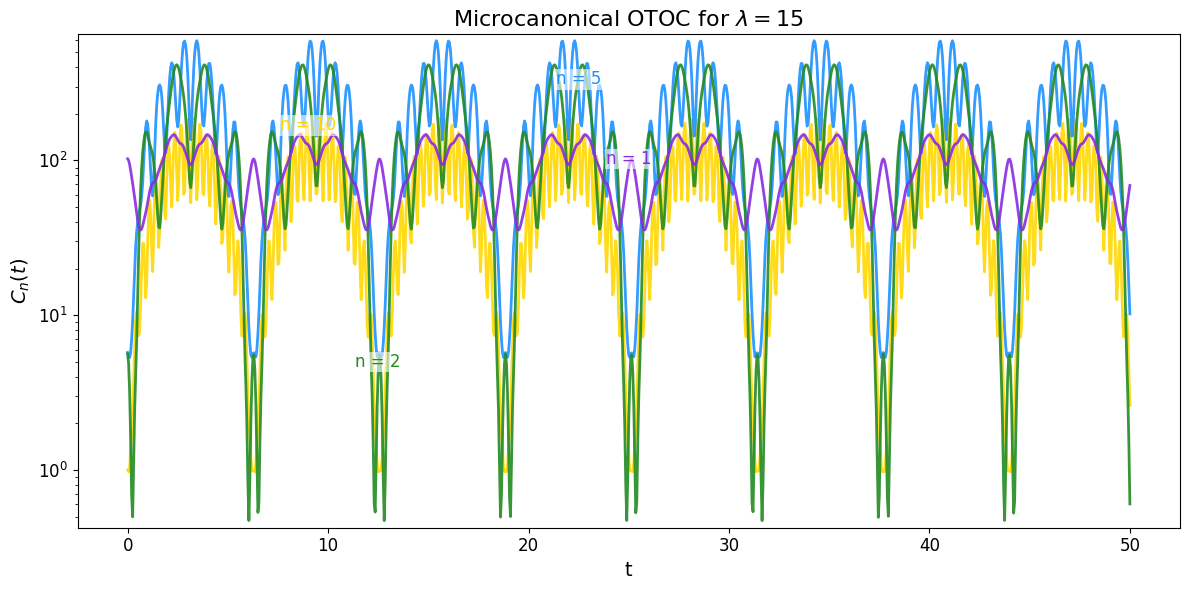

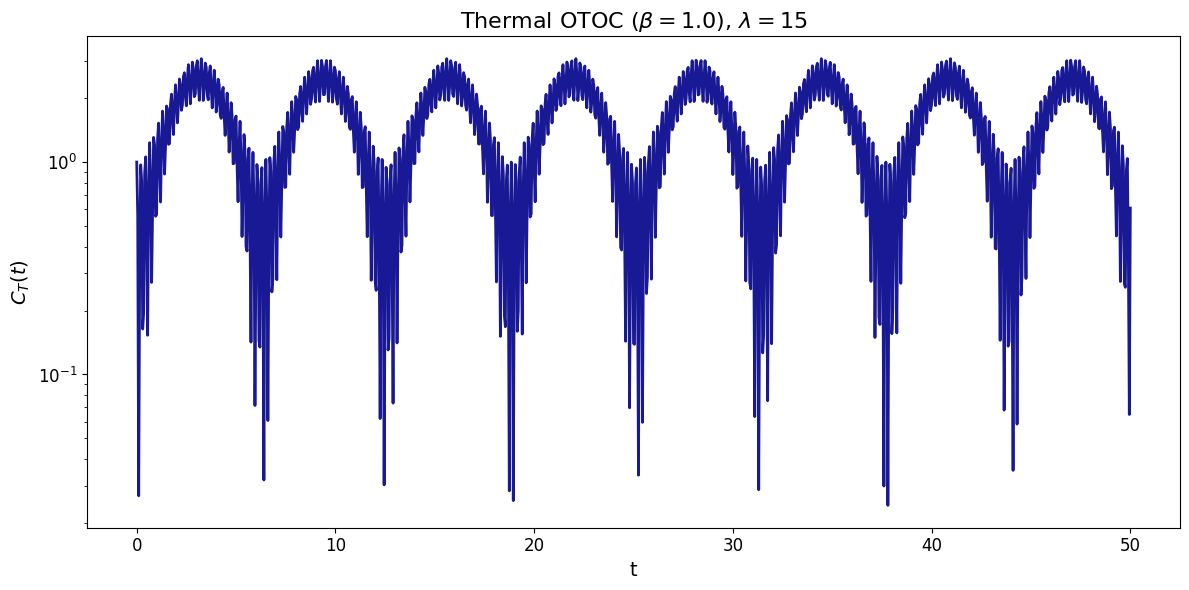

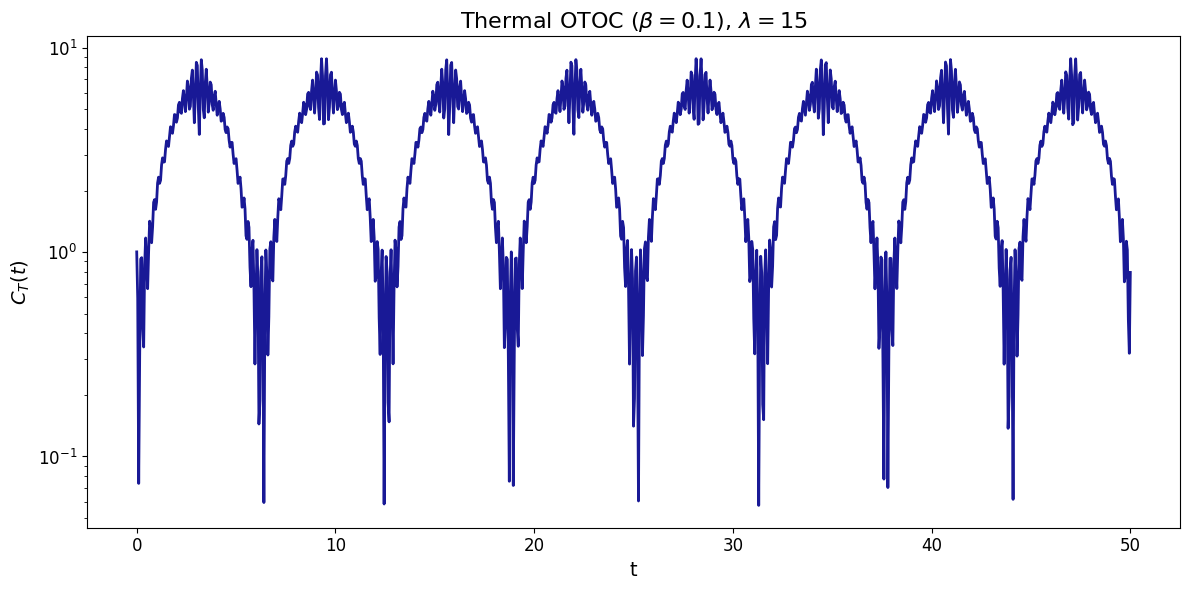

Finished processing lambda = 15.
--------------------------------------------------

All simulations are complete.


In [42]:
# --- 1. Define Simulation Parameters ---
lams_to_run = [10, 15]
time_max = 50.0
time_steps = 1001
beta_values = [1.0, 0.1]
L_box = 12.0
N_points = 20001

# --- 2. Run the Simulations ---
all_results = {}
print("Starting Pöschl-Teller OTOC computations...")
for lam_val in lams_to_run:
    results = compute_and_plot_otocs(
        lam=lam_val,
        L=L_box,
        N=N_points,
        tmax=time_max,
        nt=time_steps,
        betas=beta_values
    )
    all_results[lam_val] = results
    print("-" * 50)
print("\nAll simulations are complete.")